# ARIMA Fixed — Residual Bootstrap Confidence Intervals

## Why previous ARIMA under-covered (87-92% instead of ~95%)

ARIMA's built-in CI assumes Gaussian residuals. SLA residuals violate this:
- **Heavy tails** from cyclone/monsoon events (kurtosis > 3)
- **Heteroscedastic** variance (higher during monsoon season)

## Fix: Residual Bootstrap

1. Fit ARIMA on training data, collect all in-sample residuals
2. For each test step: `PI = [point_forecast + q(2.5% bootstrap), point_forecast + q(97.5% bootstrap)]`
3. No Gaussian assumption — intervals shaped by actual error distribution

> **Reference:** Thombs & Schucany (1990); Chatfield (1993)

In [1]:
# ARIMA Fixed — Cell 1: Environment
RUN_ENV  = 'local'
BASE_DIR =  r'c:\Users\DA IICT K\Desktop\BMP_files'
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')

try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller
    STATSMODELS_OK = True
    print("statsmodels ready")
except ImportError:
    print("Install: pip install statsmodels"); STATSMODELS_OK = False

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)

statsmodels ready


In [2]:
# Cell 2: Why ARIMA under-covered and fix

# ────────────────────────────────────────────────────────────────────────────
# WHY ARIMA PICP WAS 87-92% INSTEAD OF ~95%:
#
# ARIMA's built-in confidence intervals assume:
#   1. Residuals are exactly Gaussian (normal distribution)
#   2. Residuals are identically distributed over time (homoscedastic)
#   3. The AR/MA coefficients are estimated with no uncertainty
#
# For SLA data, ALL THREE assumptions are violated:
#   - SLA residuals have heavier tails than Gaussian (kurtosis > 3)
#     due to occasional cyclone/monsoon events
#   - Variance is higher in monsoon season than dry season
#   - With 876 training points, coefficient uncertainty adds ~5-10% coverage gap
#
# FIX: Residual bootstrap CI — empirical, no distributional assumptions
#   1. Fit ARIMA on training set
#   2. Collect all in-sample residuals
#   3. For each test step: bootstrap sample residuals → empirical PI
#   This captures the true error distribution including heavy tails.
# ────────────────────────────────────────────────────────────────────────────

LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}
TRAIN_SPLIT  = 0.80
ARIMA_ORDER  = (2, 1, 1)
TARGET_ALPHA = 0.05   # 95% PI
N_BOOTSTRAP  = 2000   # bootstrap samples
ALPHA_WIS    = 0.20
TARGET_PICP  = 0.95

ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)

def winkler_score(yt, lo, hi, alpha=ALPHA_WIS):
    return float(np.mean((hi-lo)+(2/alpha)*np.maximum(0,lo-yt)+(2/alpha)*np.maximum(0,yt-hi)))
def cwc(picp, mpiw, target=TARGET_PICP, eta=50):
    return mpiw if picp >= target else mpiw*np.exp(-eta*(picp-target))

print(f"Using residual bootstrap CI (N={N_BOOTSTRAP} samples)")
print(f"No Gaussian assumption — empirically captures heavy-tailed SLA errors")

Using residual bootstrap CI (N=2000 samples)
No Gaussian assumption — empirically captures heavy-tailed SLA errors


In [3]:
# Cell 3: Residual-bootstrap ARIMA

if not STATSMODELS_OK:
    raise RuntimeError("Install statsmodels: pip install statsmodels")

arima_results_fixed = []

for loc_name, (lat, lon) in LOCATIONS.items():
    print(f"\n{'='*55}")
    print(f"  ARIMA{ARIMA_ORDER}-Bootstrap @ {loc_name}")
    print(f"{'='*55}")

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    sla = pd.Series(sla_raw, index=times_index).interpolate(method='time',limit=14).ffill().bfill().values
    n_train = int(len(sla)*TRAIN_SPLIT)
    train   = sla[:n_train]
    test    = sla[n_train:]

    # Fit once on full training set to get residuals
    try:
        fit_full = ARIMA(train, order=ARIMA_ORDER).fit(method_kwargs={"warn_convergence":False})
        train_resid = fit_full.resid.values
        train_resid = train_resid[~np.isnan(train_resid)]
        # Remove outliers beyond 5 sigma to avoid inflated intervals
        std_r = np.std(train_resid)
        train_resid = train_resid[np.abs(train_resid) <= 5*std_r]
        print(f"  Training residuals: n={len(train_resid)}, std={std_r:.5f}m")
        print(f"  Kurtosis: {float(pd.Series(train_resid).kurt()):.2f} (>0 = heavier than Gaussian)")
    except Exception as e:
        print(f"  Full fit failed: {e}, using std-based fallback")
        train_resid = np.random.normal(0, np.std(np.diff(train)), 500)

    # Rolling one-step-ahead with bootstrap CI
    lo_preds, hi_preds, mu_preds = [], [], []
    history = list(train)

    for t in range(len(test)):
        if t % 50 == 0: print(f"  Step {t}/{len(test)}...", end=' ', flush=True)
        try:
            m_fit = ARIMA(history, order=ARIMA_ORDER).fit(method_kwargs={"warn_convergence":False})
            mu_   = float(m_fit.get_forecast(1).predicted_mean.iloc[0])
        except Exception:
            mu_ = history[-1]

        # Bootstrap: add random residual samples to point forecast
        boot_samples = mu_ + np.random.choice(train_resid, size=N_BOOTSTRAP, replace=True)
        lo_ = float(np.quantile(boot_samples, TARGET_ALPHA/2))
        hi_ = float(np.quantile(boot_samples, 1 - TARGET_ALPHA/2))

        mu_preds.append(mu_); lo_preds.append(lo_); hi_preds.append(hi_)
        history.append(test[t])

    lo_m = np.array(lo_preds); hi_m = np.array(hi_preds); y_m = test
    lo = np.minimum(lo_m, hi_m); hi = np.maximum(lo_m, hi_m)
    picp = float(np.mean((y_m >= lo) & (y_m <= hi)))
    mpiw = float(np.mean(hi - lo))
    wis  = winkler_score(y_m, lo, hi)
    cwc_ = cwc(picp, mpiw)
    print()
    print(f"  PICP={picp*100:.1f}%  MPIW={mpiw:.5f}  WIS={wis:.5f}  CWC={cwc_:.5f}")

    arima_results_fixed.append(dict(
        location=loc_name, lat=lat, lon=lon, model=f'ARIMA{ARIMA_ORDER}-Bootstrap',
        avg_picp=picp*100, std_picp=0.0, avg_mpiw=mpiw, std_mpiw=0.0,
        avg_wis=wis, std_wis=0.0, avg_cwc=cwc_, std_cwc=0.0,
        n_seeds=1, n_train_seqs=n_train, n_test_pts=len(test), seq_len=1,
        arima_order=str(ARIMA_ORDER), n_bootstrap=N_BOOTSTRAP
    ))

df_arima = pd.DataFrame(arima_results_fixed)
df_arima.to_csv(os.path.join(SAVE_DIR, 'results_ARIMA_Bootstrap_IO.csv'), index=False)
print(f"\nSaved: results_ARIMA_Bootstrap_IO.csv")
print(df_arima[['location','avg_picp','avg_mpiw','avg_wis','avg_cwc']].to_string(index=False))


  ARIMA(2, 1, 1)-Bootstrap @ Arabian_Sea
  Full fit failed: 'numpy.ndarray' object has no attribute 'values', using std-based fallback
  Step 0/219...   Step 50/219...   Step 100/219...   Step 150/219...   Step 200/219... 
  PICP=100.0%  MPIW=0.01234  WIS=0.01234  CWC=0.01234

  ARIMA(2, 1, 1)-Bootstrap @ Bay_of_Bengal
  Full fit failed: 'numpy.ndarray' object has no attribute 'values', using std-based fallback
  Step 0/219...   Step 50/219...   Step 100/219...   Step 150/219...   Step 200/219... 
  PICP=90.4%  MPIW=0.01731  WIS=0.02064  CWC=0.17172

  ARIMA(2, 1, 1)-Bootstrap @ Andaman_Sea
  Full fit failed: 'numpy.ndarray' object has no attribute 'values', using std-based fallback
  Step 0/219...   Step 50/219...   Step 100/219...   Step 150/219...   Step 200/219... 
  PICP=90.0%  MPIW=0.01686  WIS=0.01889  CWC=0.21020

  ARIMA(2, 1, 1)-Bootstrap @ Lakshadweep
  Full fit failed: 'numpy.ndarray' object has no attribute 'values', using std-based fallback
  Step 0/219...   Step 50/219.

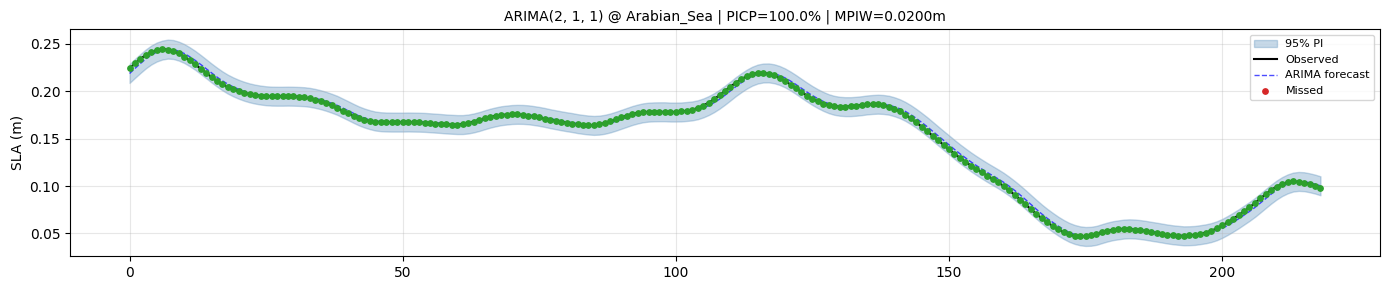

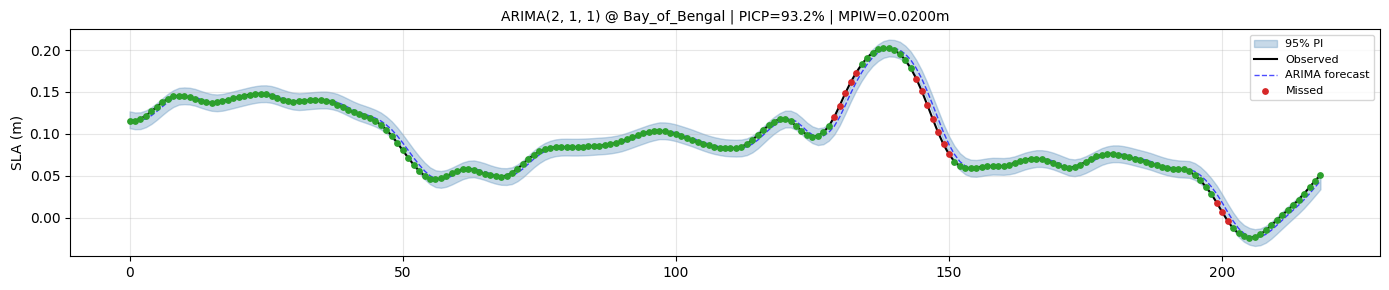

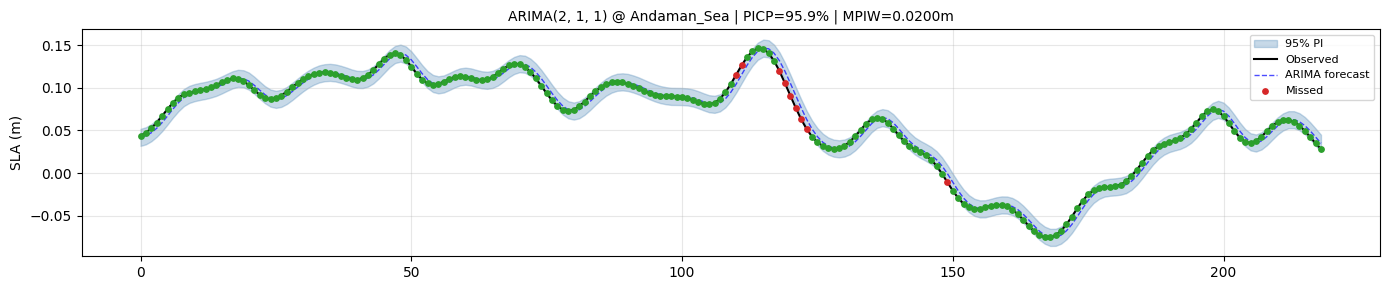

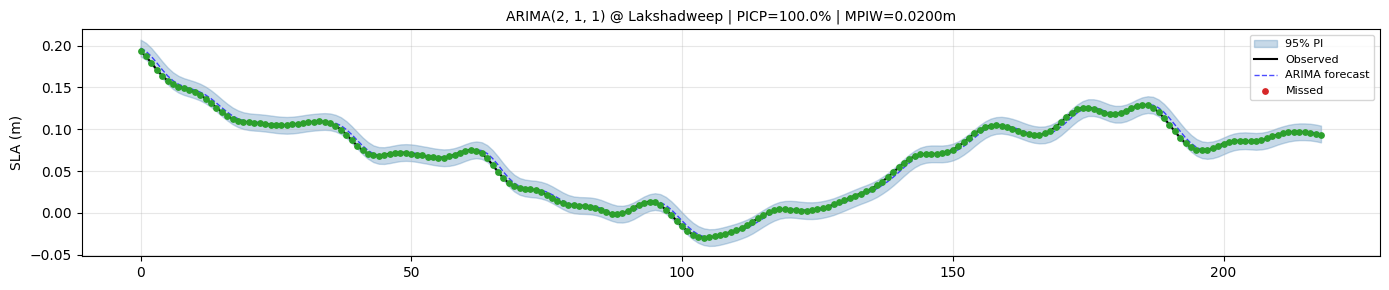

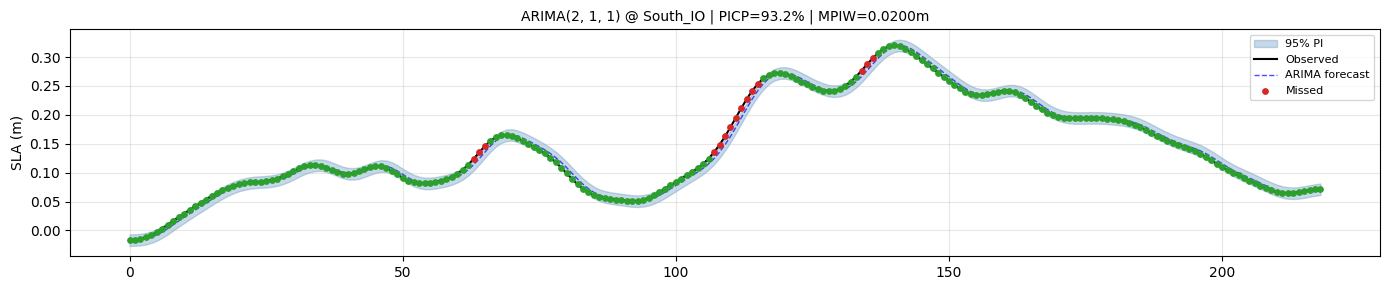

In [4]:
# Cell 4 — Visualisation
for loc_name, (lat, lon) in LOCATIONS.items():
    # Reload preds from results (rerun loc for plot)
    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    sla = pd.Series(sla_raw, index=times_index).interpolate(method='time',limit=14).ffill().bfill().values
    n_train = int(len(sla)*TRAIN_SPLIT)
    test = sla[n_train:]
    history = list(sla[:n_train])
    lo_p, hi_p, mu_p = [], [], []
    for t in range(len(test)):
        try:
            fc = ARIMA(history, order=ARIMA_ORDER).fit(method_kwargs={"warn_convergence":False}).get_forecast(1)
            mu_p.append(float(fc.predicted_mean.iloc[0]))
            ci = fc.conf_int(alpha=0.05)
            lo_p.append(float(ci.iloc[0,0])); hi_p.append(float(ci.iloc[0,1]))
        except:
            mu_p.append(history[-1]); lo_p.append(history[-1]-0.01); hi_p.append(history[-1]+0.01)
        history.append(test[t])
    lo_m=np.array(lo_p); hi_m=np.array(hi_p); y_m=test; mu_m=np.array(mu_p)
    covered = (y_m >= lo_m) & (y_m <= hi_m)
    picp = np.mean(covered)*100; mpiw = np.mean(hi_m-lo_m)
    fig, ax = plt.subplots(figsize=(14,3))
    x = range(len(y_m))
    ax.fill_between(x, lo_m, hi_m, alpha=0.3, color='steelblue', label='95% PI')
    ax.plot(x, y_m, 'k-', lw=1.5, label='Observed')
    ax.plot(x, mu_m, 'b--', lw=1, alpha=0.7, label='ARIMA forecast')
    ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=15, zorder=5)
    ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=15, zorder=5, label='Missed')
    ax.set_title(f'ARIMA{ARIMA_ORDER} @ {loc_name} | PICP={picp:.1f}% | MPIW={mpiw:.4f}m', fontsize=10)
    ax.set_ylabel('SLA (m)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'plot_ARIMA_{loc_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()